    Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  Atmospheric Pressure  UV Index  Season  Visibility (km)  Location Weather Type
0          14.0        73         9.5               82.0  partly cloudy               1010.82         2  Winter              3.5    inland        Rainy
1          39.0        96         8.5               71.0  partly cloudy               1011.43         7  Spring             10.0    inland       Cloudy
2          30.0        64         7.0               16.0          clear               1018.72         5  Spring              5.5  mountain        Sunny
3          38.0        83         1.5               82.0          clear               1026.25         7  Spring              1.0   coastal        Sunny
4          27.0        74        17.0               66.0       overcast                990.67         1  Winter              2.5  mountain        Rainy
5          32.0        55         3.5               26.0       overcast               10

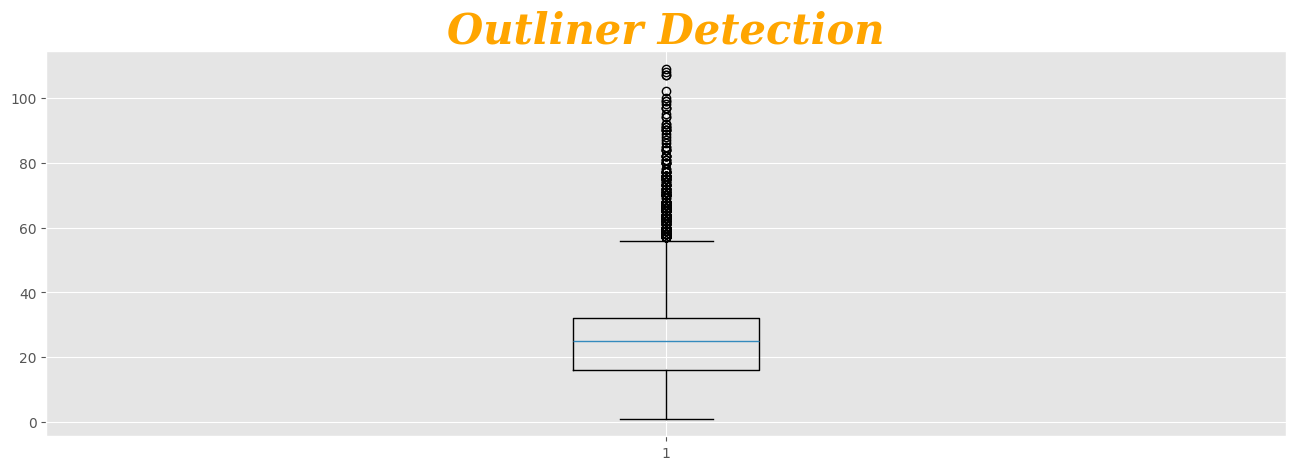

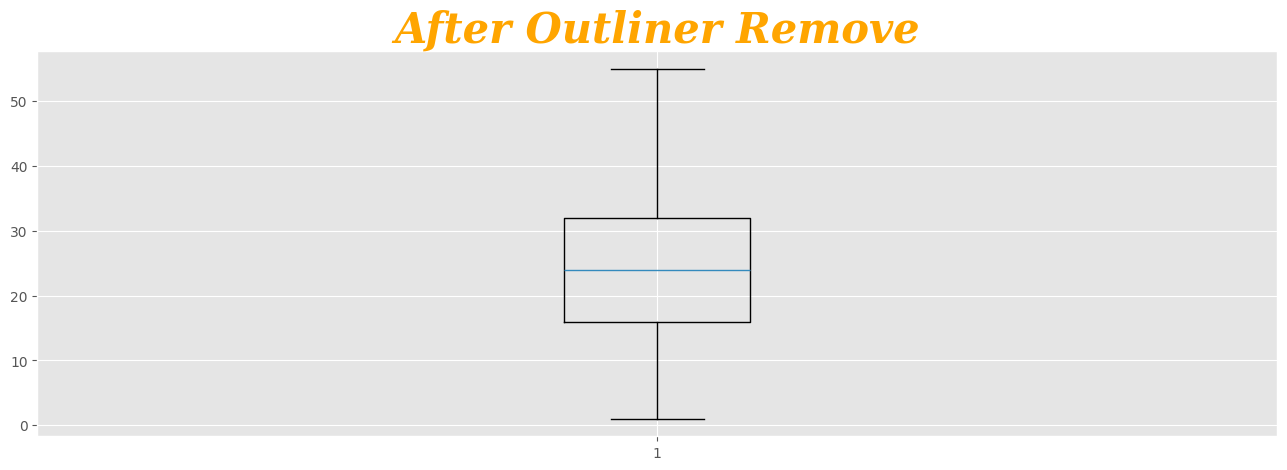

    Temperature  Humidity  Wind Speed  Precipitation (%)  Cloud Cover  Atmospheric Pressure  UV Index  Season  Visibility (km)  Location Weather Type
0          14.0        73         9.5               82.0            3               1010.82         2       3              3.5         1        Rainy
1          39.0        96         8.5               71.0            3               1011.43         7       1             10.0         1       Cloudy
2          30.0        64         7.0               16.0            0               1018.72         5       1              5.5         2        Sunny
3          38.0        83         1.5               82.0            0               1026.25         7       1              1.0         0        Sunny
4          27.0        74        17.0               66.0            2                990.67         1       3              2.5         2        Rainy
5          32.0        55         3.5               26.0            2               1010.03         

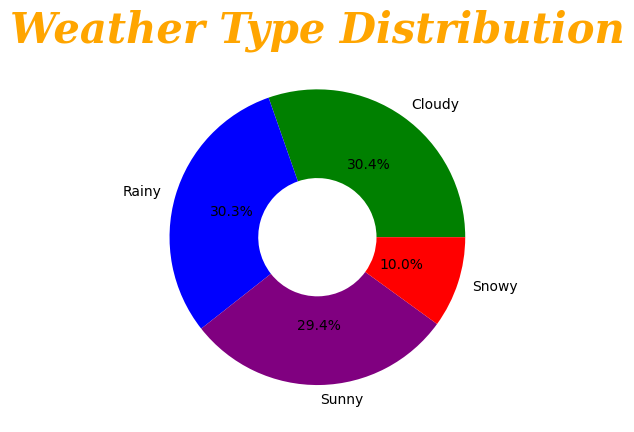

CVS ==  [0.91815118 0.92296582 0.90414258 0.90558767 0.91377649]
Average OF CVS ==  0.9129247478809569


Train Score == 0.9207706201083684
Test SCore == 0.9037072701011074


Accuracy Score :
90.37072701011074 %


Confusion Matrix : 
[[596  23   4   1]
 [ 52 556   4   0]
 [ 41   9 169   2]
 [ 48  11   5 556]]


Classification Report : 
              precision    recall  f1-score   support

      Cloudy       0.81      0.96      0.88       624
       Rainy       0.93      0.91      0.92       612
       Snowy       0.93      0.76      0.84       221
       Sunny       0.99      0.90      0.94       620

    accuracy                           0.90      2077
   macro avg       0.92      0.88      0.89      2077
weighted avg       0.91      0.90      0.90      2077



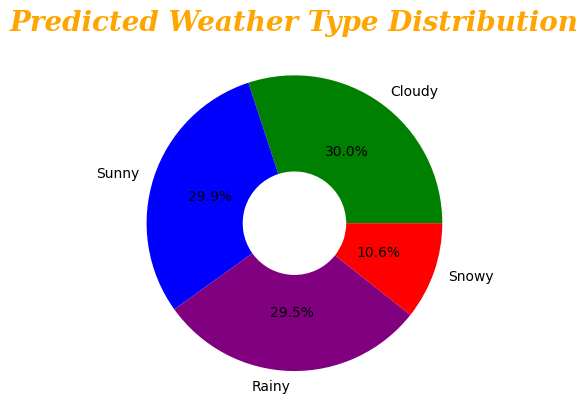

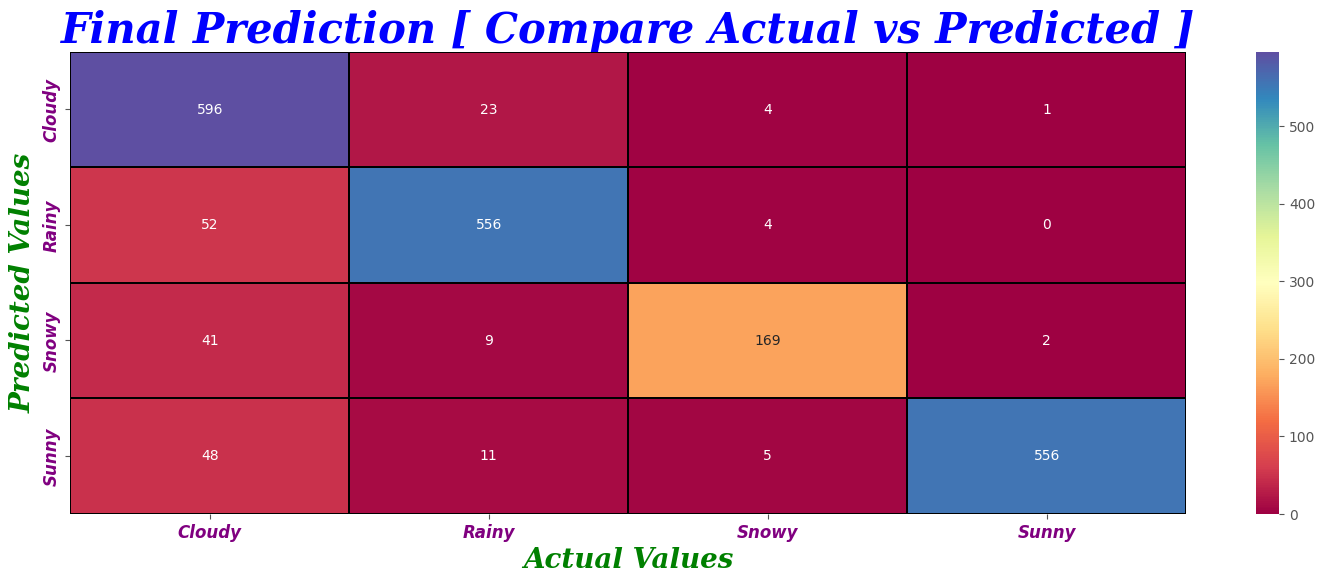

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv("weather_classification_data.csv")
print(JP.head(30))

print(JP.isna().sum())
# JP=JP[JP.duplicated()]
# print(JP)

# print(JP['Temperature'].sort_values().head(20))
JP=JP.query(" Temperature > 0 ")
# print(JP['Temperature'].sort_values().head(20))

plt.figure(figsize=(16,5))
plt.boxplot(JP['Temperature'])
plt.title("Outliner Detection",fontsize=30,fontweight='bold',color='orange',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

Q1=JP['Temperature'].quantile(0.25)
Q3=JP['Temperature'].quantile(0.75)

IQR=Q3 - Q1

lower= Q1 - 1.5 * IQR
upper= Q3 + 1.5 * IQR

JP=JP [ ( JP['Temperature'] > lower) & ( JP['Temperature'] < upper) ]

plt.figure(figsize=(16,5))
plt.boxplot(JP['Temperature'])
plt.title("After Outliner Remove",fontsize=30,fontweight='bold',color='orange',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

from sklearn.preprocessing import LabelEncoder

JP['Cloud Cover']=LabelEncoder().fit_transform(JP['Cloud Cover'])
JP['Season']=LabelEncoder().fit_transform(JP['Season'])
JP['Location']=LabelEncoder().fit_transform(JP['Location'])

print(JP.head(20))

print("Number OF Rows & Columns == ",JP.shape)

ABC=JP['Weather Type'].value_counts()
print(ABC)

plt.pie(JP['Weather Type'].value_counts(),labels=JP['Weather Type'].value_counts().index,colors=['green','blue','purple','red'],wedgeprops=dict(width=0.6),autopct='%1.1f%%')
plt.title("Weather Type Distribution",fontsize=30,fontweight='bold',color='orange',fontdict={'family':'serif'},fontstyle='italic')
plt.show()


x=JP[[
        'Temperature','Humidity','Wind Speed','Precipitation (%)','Cloud Cover','Atmospheric Pressure','UV Index',
        'Season','Visibility (km)','Location'
    ]]
y=JP['Weather Type']

from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=5)

score=cross_val_score(model,x,y,cv=5,scoring='accuracy')

print("CVS == ",score)
print("Average OF CVS == ",score.mean())


from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=25)


from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=5,random_state=89)

model.fit(x_train,y_train)
Y_Pred=model.predict(x_test)


# from sklearn.ensemble import RandomForestClassifier

# model=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=56)

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)


# from sklearn.neighbors import KNeighborsClassifier

# model=KNeighborsClassifier(n_neighbors=5,weights='uniform')

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)


# from sklearn.linear_model import LogisticRegression

# model=LogisticRegression(max_iter=1000)

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)



from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

Train=model.score(x_train,y_train)
Test=model.score(x_test,y_test)

print("\n")
print("Train Score ==",Train)
print("Test SCore ==",Test)

print("\n")
print("Accuracy Score :")
print(accuracy_score(y_test,Y_Pred) * 100 ,"%")

print("\n")
print("Confusion Matrix : ")
CM=confusion_matrix(y_test,Y_Pred)
print(CM)

print("\n")
print("Classification Report : ")
print(classification_report(y_test,Y_Pred))

plt.pie(y_test.value_counts(),labels=y_test.value_counts().index,colors=['green','blue','purple','red'],wedgeprops=dict(width=0.65),autopct='%1.1f%%')
plt.title("Predicted Weather Type Distribution",fontsize=20,fontweight='bold',color='orange',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

plt.figure(figsize=(18,6))
sns.heatmap(CM,annot=True,fmt='d',cmap='Spectral',xticklabels=['Cloudy','Rainy','Snowy','Sunny'],yticklabels=['Cloudy','Rainy','Snowy','Sunny'],linewidths=0.2,linecolor='black')
plt.title("Final Prediction [ Compare Actual vs Predicted ]",fontsize=30,fontweight='bold',color='blue',fontdict={'family':'serif'},fontstyle='italic')
plt.xlabel("Actual Values",fontsize=20,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')
plt.ylabel("Predicted Values",fontsize=20,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')
plt.xticks(fontsize=12,fontweight='bold',fontstyle='italic',color='purple')
plt.yticks(fontsize=12,fontweight='bold',fontstyle='italic',color='purple')
plt.show()